In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Bond Portfolio

In [2]:
asset_values = np.array([500000, 300000, 200000])
asset_durations = np.array([2.5, 5.0, 8.0])
asset_convexities = np.array([12, 35, 60])


liability_value = 1000000
liability_duration = 4.8
liability_convexity = 30

In [ ]:
# Portfolio Duration

In [5]:

weights = asset_values / asset_values.sum()

portfolio_duration = np.sum(weights * asset_durations)

print(f"Portfolio Duration: {portfolio_duration:.2f}")
print(f"Liability Duration: {liability_duration:.2f}")

Portfolio Duration: 4.35
Liability Duration: 4.80


In [ ]:
# Portfolio Convexity

In [6]:
portfolio_convexity = np.sum(weights * asset_convexities)

print(f"Portfolio Convexity: {portfolio_convexity:.2f}")
print(f"Liability Convexity: {liability_convexity:.2f}")

Portfolio Convexity: 28.50
Liability Convexity: 30.00


In [ ]:
# Duration Gap Analysis

In [7]:
duration_gap = portfolio_duration - liability_duration

print(f"Duration Gap: {duration_gap:.2f}")

if abs(duration_gap) < 0.1:
    print("Portfolio is approximately immunized.")
else:
    print("Portfolio requires rebalancing.")

Duration Gap: -0.45
Portfolio requires rebalancing.


In [ ]:
#Rebalancing

In [8]:
#Suppose interest rates change and bond durations shift

new_asset_durations = np.array([2.2, 4.6, 7.5])
new_portfolio_duration = np.sum(weights * new_asset_durations)

print(f"New Portfolio Duration: {new_portfolio_duration:.2f}")
print(f"Target Liability Duration: {liability_duration:.2f}")

New Portfolio Duration: 3.98
Target Liability Duration: 4.80


In [ ]:
#Interest Rate Shock Simulation

In [9]:
#This section measures how the portfolio and liabilities react to parallel shifts in interest rates.

# Simulated interest rate shocks
rate_shocks = np.array([-2, -1, 0, 1, 2])

# Approximate price impact using duration-convexity relationship
asset_price_change = (
    -portfolio_duration * (rate_shocks/100)
    + 0.5 * portfolio_convexity * (rate_shocks/100)**2
)

liability_price_change = (
    -liability_duration * (rate_shocks/100)
    + 0.5 * liability_convexity * (rate_shocks/100)**2
)

shock_df = pd.DataFrame({
    'Rate Shock (%)': rate_shocks,
    'Asset Change (%)': asset_price_change * 100,
    'Liability Change (%)': liability_price_change * 100
})

print(shock_df)

   Rate Shock (%)  Asset Change (%)  Liability Change (%)
0              -2            9.2700                 10.20
1              -1            4.4925                  4.95
2               0            0.0000                  0.00
3               1           -4.2075                 -4.65
4               2           -8.1300                 -9.00


In [ ]:
#Funding Ratio Analysis

In [10]:
portfolio_value = asset_values.sum()
funding_ratio = portfolio_value / liability_value

print(f"Funding Ratio: {funding_ratio:.2f}")

if funding_ratio >= 1:
    print("Portfolio is fully funded.")
else:
    print("Portfolio is underfunded.")

Funding Ratio: 1.00
Portfolio is fully funded.


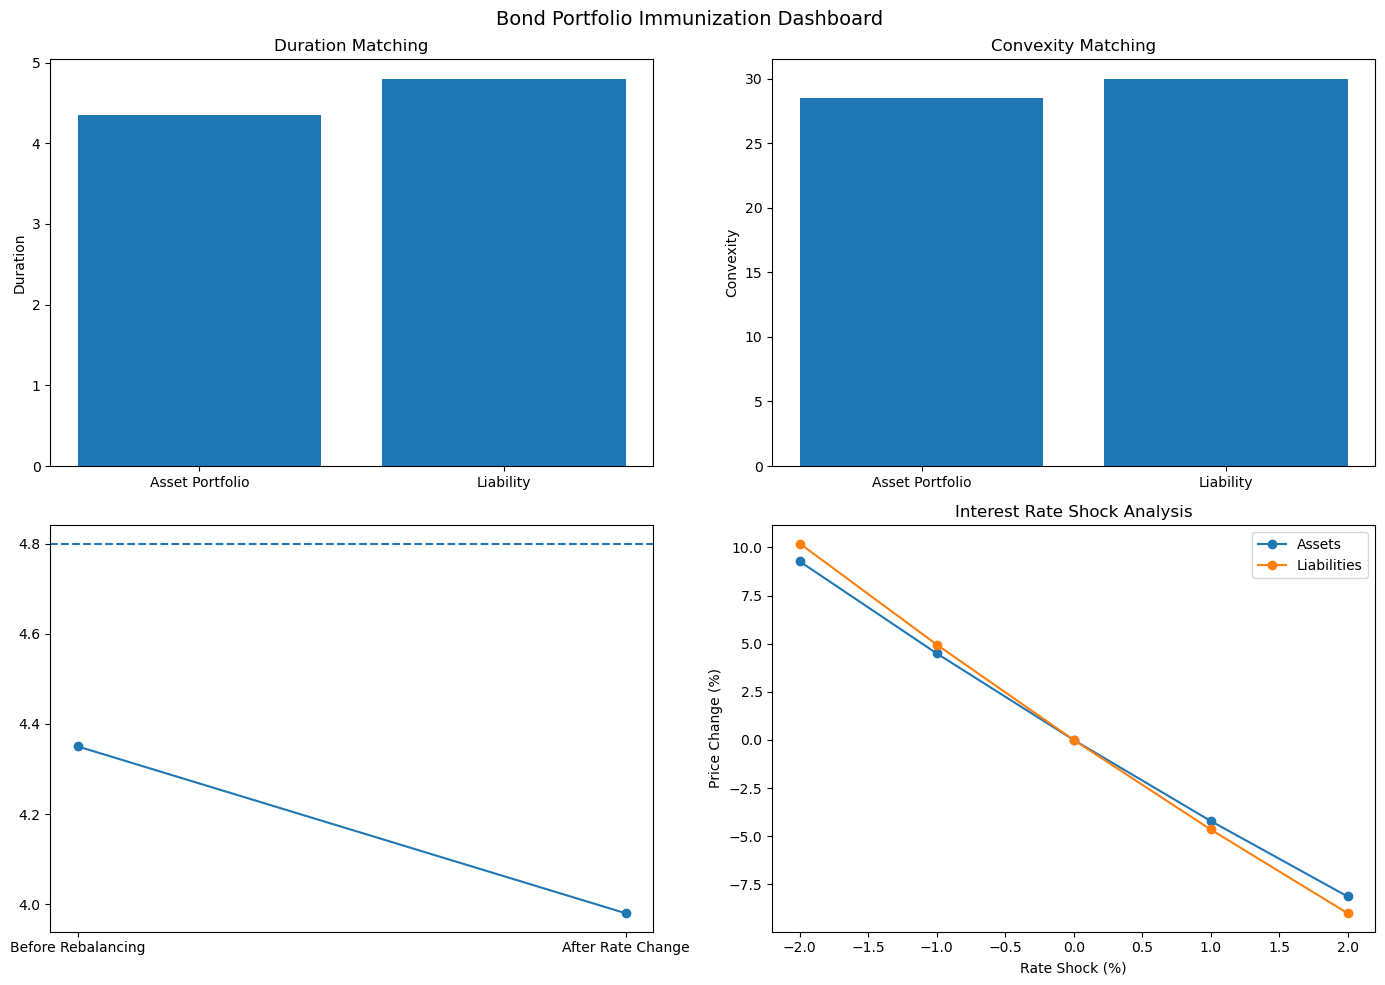

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

#Duration Matching 
labels = ['Asset Portfolio', 'Liability']
durations = [portfolio_duration, liability_duration]

axes[0].bar(labels, durations)
axes[0].set_title('Duration Matching')
axes[0].set_ylabel('Duration')

#Convexity Matching 
convexities = [portfolio_convexity, liability_convexity]

axes[1].bar(labels, convexities)
axes[1].set_title('Convexity Matching')
axes[1].set_ylabel('Convexity')

#Rebalancing Impact
before_after = [portfolio_duration, new_portfolio_duration]

axes[2].plot(
    ['Before Rebalancing', 'After Rate Change'],
    before_after,
    marker='o'
)

axes[2].axhline(
    liability_duration,
    linestyle='--',
    label='Liability Duration'
)

#Interest Rate Shock Sensitivity
axes[3].plot(rate_shocks, asset_price_change * 100, marker='o', label='Assets')
axes[3].plot(rate_shocks, liability_price_change * 100, marker='o', label='Liabilities')
axes[3].set_title('Interest Rate Shock Analysis')
axes[3].set_xlabel('Rate Shock (%)')
axes[3].set_ylabel('Price Change (%)')
axes[3].legend()

plt.suptitle('Bond Portfolio Immunization Dashboard', fontsize=14)
plt.tight_layout()
plt.show()